100%|██████████| 9.91M/9.91M [00:00<00:00, 60.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.36MB/s]


Epoch [1/10] | G Loss: 7.3713 | D Loss: 0.0200
Epoch [2/10] | G Loss: 2.8663 | D Loss: 1.3199
Epoch [3/10] | G Loss: 1.6378 | D Loss: 1.2693
Epoch [4/10] | G Loss: 3.3381 | D Loss: 0.9302
Epoch [5/10] | G Loss: 2.1436 | D Loss: 0.4613
Epoch [6/10] | G Loss: 5.4830 | D Loss: 0.4915
Epoch [7/10] | G Loss: 2.2672 | D Loss: 0.7884
Epoch [8/10] | G Loss: 1.6172 | D Loss: 0.4989
Epoch [9/10] | G Loss: 1.8540 | D Loss: 1.1149
Epoch [10/10] | G Loss: 1.6420 | D Loss: 0.9926


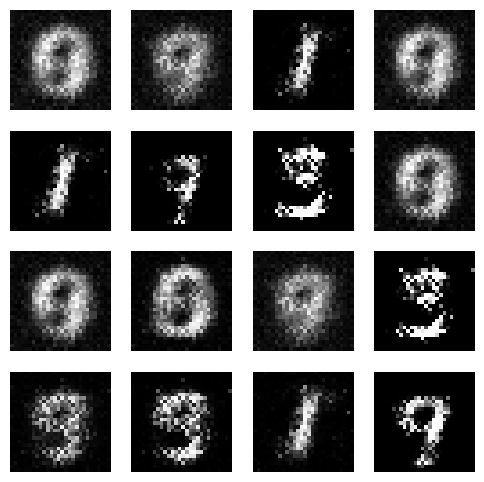

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Step 1 – Load MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

# Step 2 – Generator Model
generator = nn.Sequential(
    nn.Linear(100, 256),
    nn.ReLU(),
    nn.Linear(256, 512),
    nn.ReLU(),
    nn.Linear(512, 1024),
    nn.ReLU(),
    nn.Linear(1024, 784),
    nn.Tanh()
)

# Step 3 – Discriminator Model
discriminator = nn.Sequential(
    nn.Linear(784, 512),
    nn.LeakyReLU(0.2),
    nn.Linear(512, 256),
    nn.LeakyReLU(0.2),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

# Step 4 – Loss Function
loss_function = nn.BCELoss()

# Step 5 – Optimizers
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=0.0002)
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=0.0002)

# Step 6 – Training
epochs = 10

for epoch in range(epochs):
    for images, _ in dataloader:

        # Prepare real data
        real_images = images.view(-1, 784)
        real_labels = torch.ones(real_images.size(0), 1)
        fake_labels = torch.zeros(real_images.size(0), 1)

        # ---------------------
        # Train Discriminator
        # ---------------------
        outputs = discriminator(real_images)
        loss_real = loss_function(outputs, real_labels)

        noise = torch.randn(real_images.size(0), 100)
        fake_images = generator(noise)

        outputs = discriminator(fake_images.detach())
        loss_fake = loss_function(outputs, fake_labels)

        loss_discriminator = loss_real + loss_fake

        optimizer_discriminator.zero_grad()
        loss_discriminator.backward()
        optimizer_discriminator.step()

        # ---------------------
        # Train Generator
        # ---------------------
        noise = torch.randn(real_images.size(0), 100)
        fake_images = generator(noise)

        outputs = discriminator(fake_images)
        loss_generator = loss_function(outputs, real_labels)

        optimizer_generator.zero_grad()
        loss_generator.backward()
        optimizer_generator.step()

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"G Loss: {loss_generator.item():.4f} | "
          f"D Loss: {loss_discriminator.item():.4f}")

# Step 7 – Generate Images
noise = torch.randn(16, 100)
generated_images = generator(noise)
generated_images = generated_images.view(16, 28, 28).detach().numpy()

# Step 8 – Display Images
plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i], cmap='gray')
    plt.axis('off')

plt.show()